In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_ivp
# import sympy as sp
import os

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'


import matplotlib.pyplot as plt

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

#colors = ['#3C536D', '#DAC746', '#3390D7', '#DC4D57', '#237b68', '#B0705F']
import matplotlib as mpl

# Use a serif font for all text
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Set global font size
mpl.rcParams['mathtext.fontset'] = 'stix'  # Use Times-compatible math fonts
mpl.rcParams['axes.titlesize'] = 16  # Larger title font
mpl.rcParams['axes.labelsize'] = 14  # Larger axis label font

In [2]:
# Armemos un código para graficar las perturbaciones
def pert(t, y, k, g_mplm2):
    phi, phi_dot, dphi_k, dphi_dot_k, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**2/2)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi
    
    # Ecuaciones para δφ_k
    dphi_ddot_k = -3 * H * dphi_dot_k - (k**2 / a**2 + 1) * dphi_k
    
    # Ecuaciones para χ_k
    chi_ddot_k = -3 * H * chi_dot_k - (k**2 / a**2 + g_mplm2 * phi**2) * chi_k
    # chi_ddot_k = - (k**2 / a**2 + g_mplm2 * phi**2) * chi_k
    
    return [phi_dot, phi_ddot, dphi_dot_k, dphi_ddot_k, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

In [3]:
q = 3e3
Ak = 2*q+1

g = 1e-1
mpl_m = 1e6 #m_pl / m

k = np.sqrt(Ak - 2 * q ) 
g_mplm2 = q**2 #( g * mpl_m )**2

# print(f'Ak = {Ak}')
# print(f'q = {q}')

In [4]:
# Rango de tiempo de integración
nf = 10
t0, tf = 0, nf * np.pi
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1#1/np.sqrt(np.pi)
phiprime0 = phi0
a_rh = 1
aprime_rh = a_rh * phi0 / np.sqrt(3)

# Perturbaciones
Omega_phi = k**2/a_rh**2 + 3 * phi0**2
Omega_chi = k**2/a_rh**2 + g**2 * phi0**2
dphi_k0 = 0#1/np.sqrt(2 * Omega_phi)
dphi_dot_k0 = 0#1/np.sqrt(2 * Omega_phi)
chi_k0 = 0#1/np.sqrt(2 * Omega_chi)
chi_dot_k0 = 1#1/np.sqrt(2 * Omega_chi)#0

y0 = [phi0, phiprime0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, a_rh, aprime_rh]

In [5]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g_mplm2), t_eval=t_eval, method = "Radau", rtol=1e-8, atol=1e-8)

In [6]:
# Extraemos los resultados
t_sol = sol.t
phi_sol = sol.y[0]
a_sol = sol.y[6]
adot_sol = sol.y[7]

#dphi_sol = sol.y[2]
chi_sol = sol.y[4]
chidot_sol = sol.y[5]

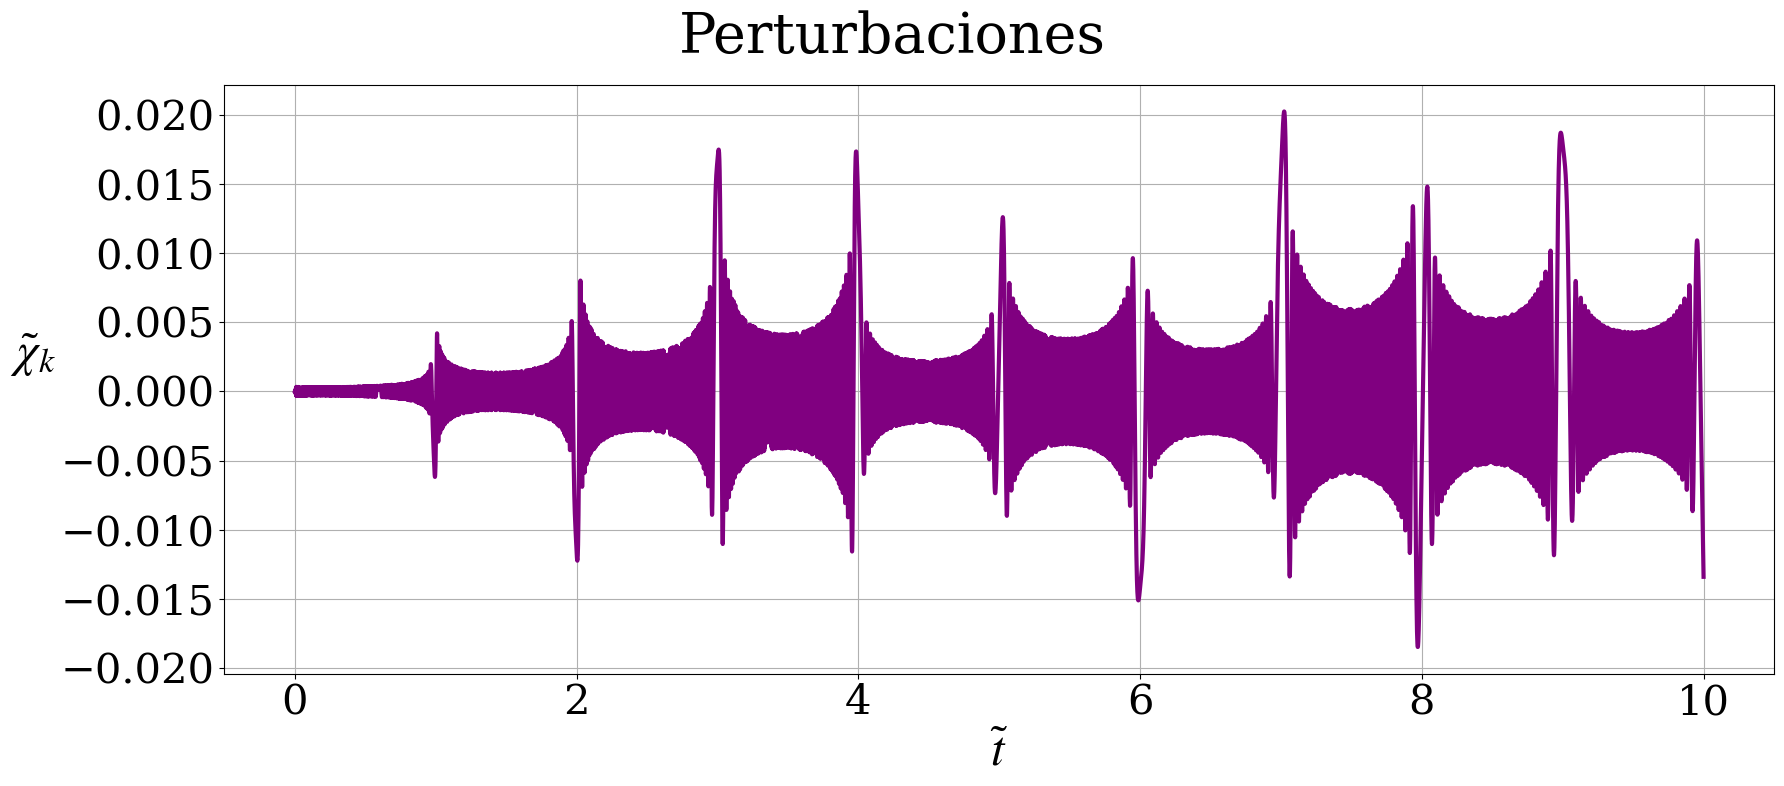

In [7]:
plt.figure(figsize = (18, 8))

plt.plot(sol.t/np.pi, (sol.y[6]/a_rh)**(3/2)*chi_sol, lw = 3, color = "purple")
plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal", fontsize=35)
plt.xlabel(r"$\tilde{t}$", fontsize=35)
plt.grid()
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.suptitle("Perturbaciones", fontsize=40)
plt.tight_layout()
#plt.show()

plt.savefig("Mathieu_pert", format='pdf')

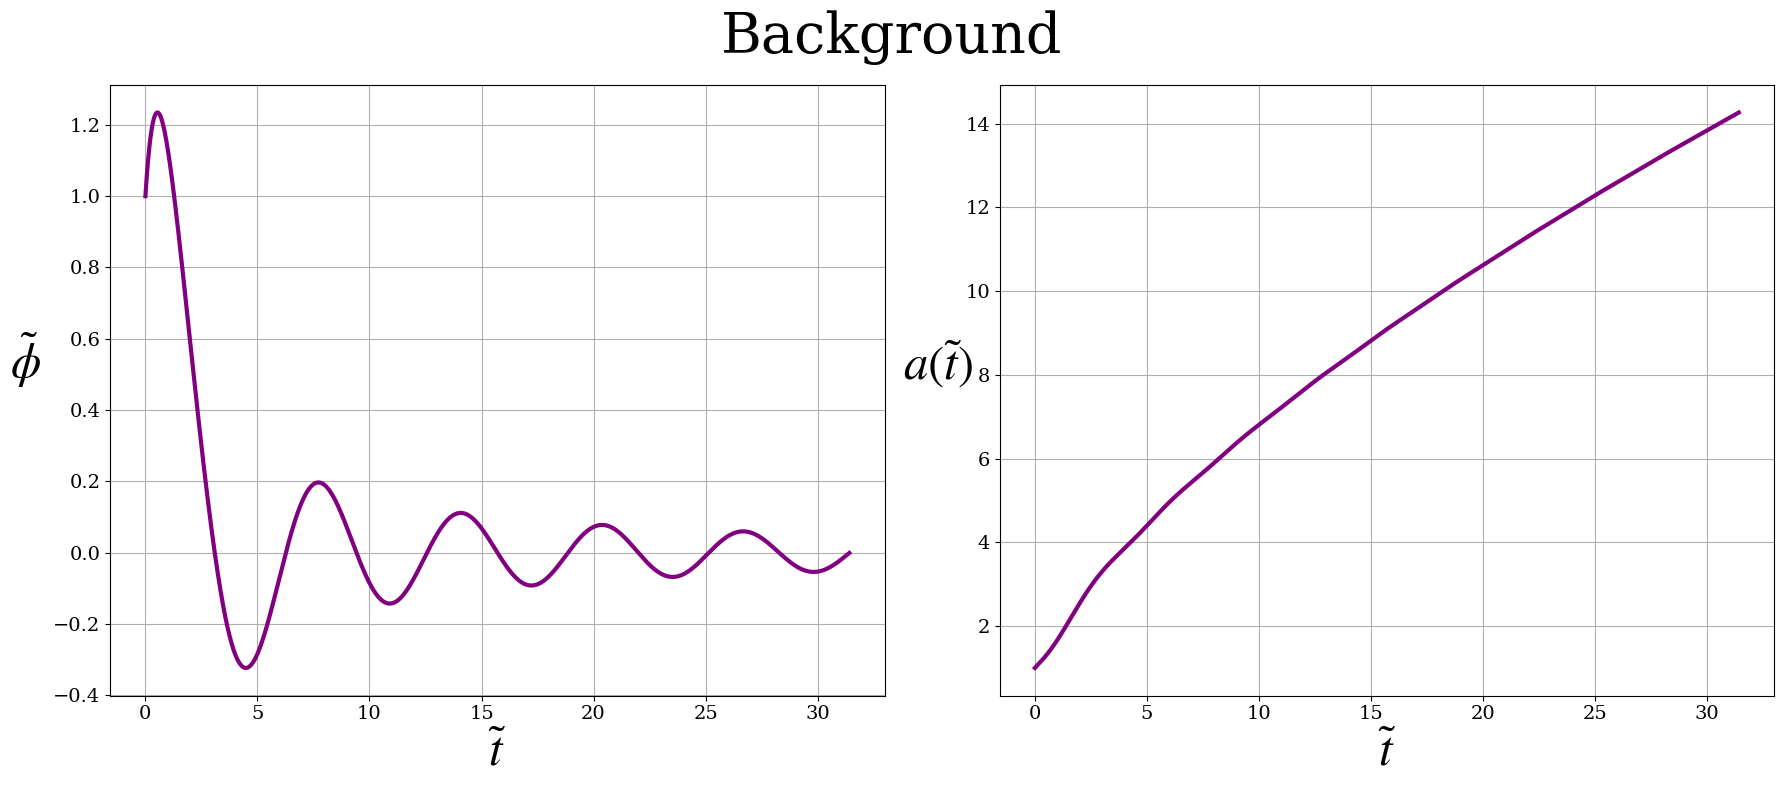

In [8]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, phi_sol, lw = 3, color = "purple")
plt.ylabel(r"$\tilde{\phi}$", labelpad = 20, rotation = "horizontal", fontsize=35)
plt.xlabel(r"$\tilde{t}$", fontsize=35)
plt.grid()

plt.subplot(1,2,2)
plt.plot(sol.t, a_sol, lw = 3, color = "purple")
plt.ylabel(r"$a (\tilde{t})$", labelpad = 20, rotation = "horizontal", fontsize=35)
plt.xlabel(r"$\tilde{t}$", fontsize=35)
plt.grid()

plt.suptitle("Background", fontsize=40)
plt.tight_layout()
#plt.show()

plt.savefig("Mathieu_background", format='pdf')

In [9]:
x_dot = (3/2)*np.sqrt(a_sol/a_sol[0]) * adot_sol / a_sol[0] * chi_sol + (a_sol/a_sol[0])**(3/2) * chidot_sol

x = (a_sol/a_sol[0])**(3/2) * chi_sol

omega_k = np.sqrt( (k/a_sol)**2 + g_mplm2 * phi_sol**2 ) # - (3/2) Hprime - 9/4H**2

nk = omega_k / 2 * ( np.abs(x_dot)**2 / omega_k**2 + np.abs(x)**2 )

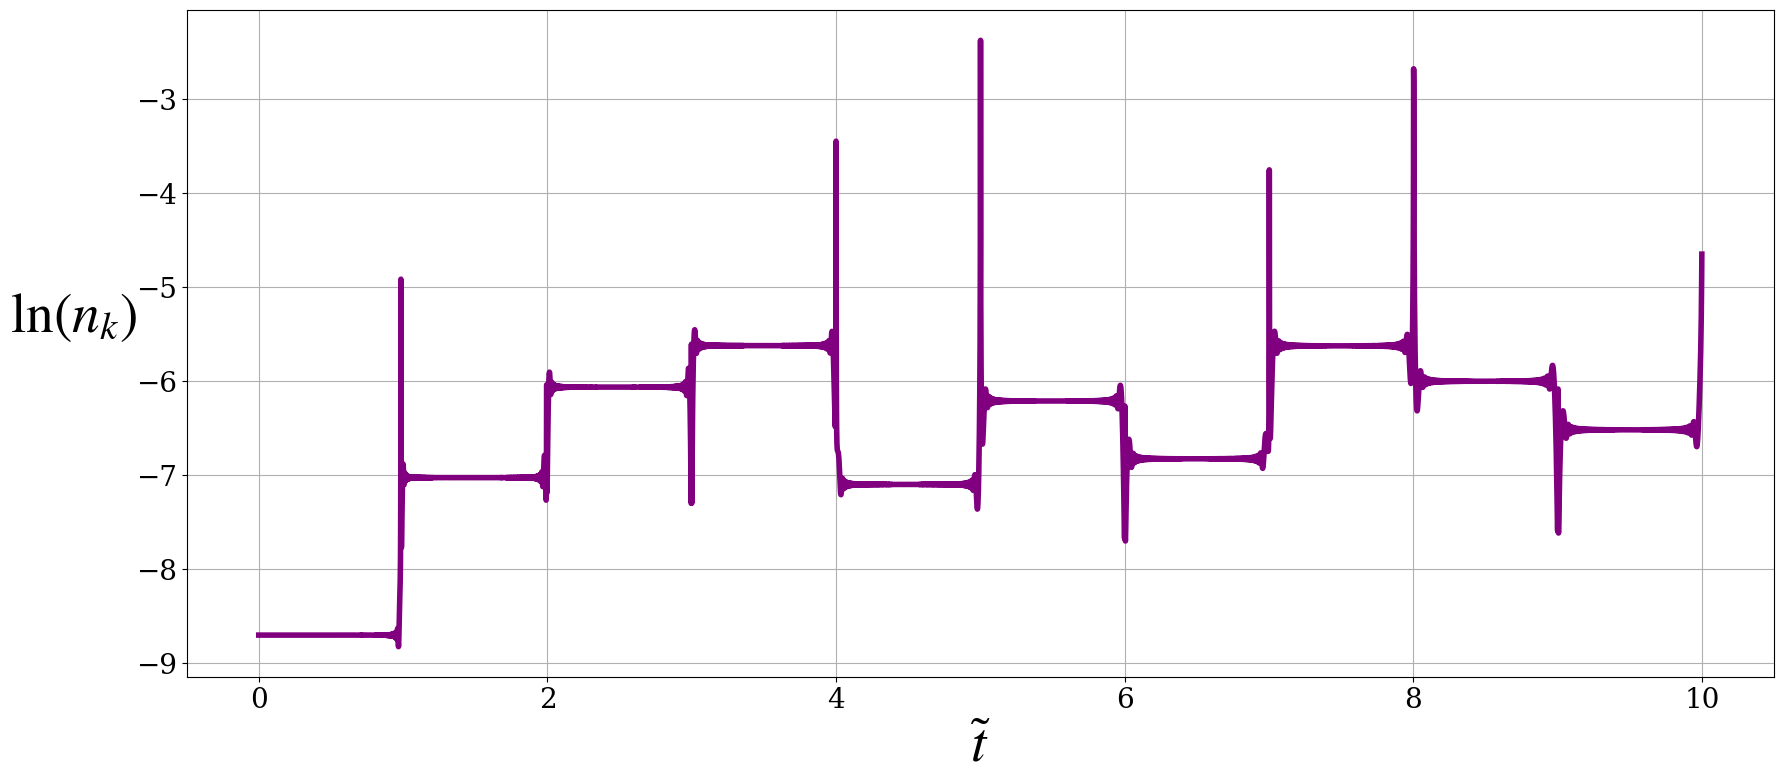

In [10]:
plt.figure(figsize = (18, 8))

plt.plot(sol.t/np.pi, np.log(nk), lw = 4, color = "purple")
plt.ylabel(r"$\ln(n_k)$", labelpad = 45, rotation = "horizontal", fontsize = 40)
plt.xlabel(r"$\tilde{t}$", fontsize = 40)
plt.grid()

plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.tight_layout()
#plt.show()

plt.savefig("stochastic_resonance", format = "pdf")

$$q = \frac{g^2}{4} \left( \frac{\phi_0}{m} \right)^2; \hspace{3cm} A_k = \left( \frac{k}{m} \right)^2 + 2 q; \hspace{3cm} T = m t + \frac{\pi}{2}$$

In [11]:
# Narrow resonance parameters
q = 0.1
Ak = 2*q + 1
g = 1e-1
mpl_m = 1e6
k = np.sqrt(Ak - 2 * q)
g_mplm2 = q  # For narrow resonance, g_mplm2 should be small

# Rango de tiempo de integración
nf = 10
t0, tf = 0, nf * np.pi
t_eval = np.linspace(t0, tf, int(1e4))

# Background
phi0 = 2 * np.sqrt(q)/g
phiprime0 = phi0
a_rh = 1
aprime_rh = a_rh * phi0 / np.sqrt(3)

# Perturbaciones
Omega_phi = k**2/a_rh**2 + 3 * phi0**2
Omega_chi = k**2/a_rh**2 + g**2 * phi0**2
dphi_k0 = 0
dphi_dot_k0 = 0
chi_k0 = 0
chi_dot_k0 = 1

y0 = [phi0, phiprime0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, a_rh, aprime_rh]

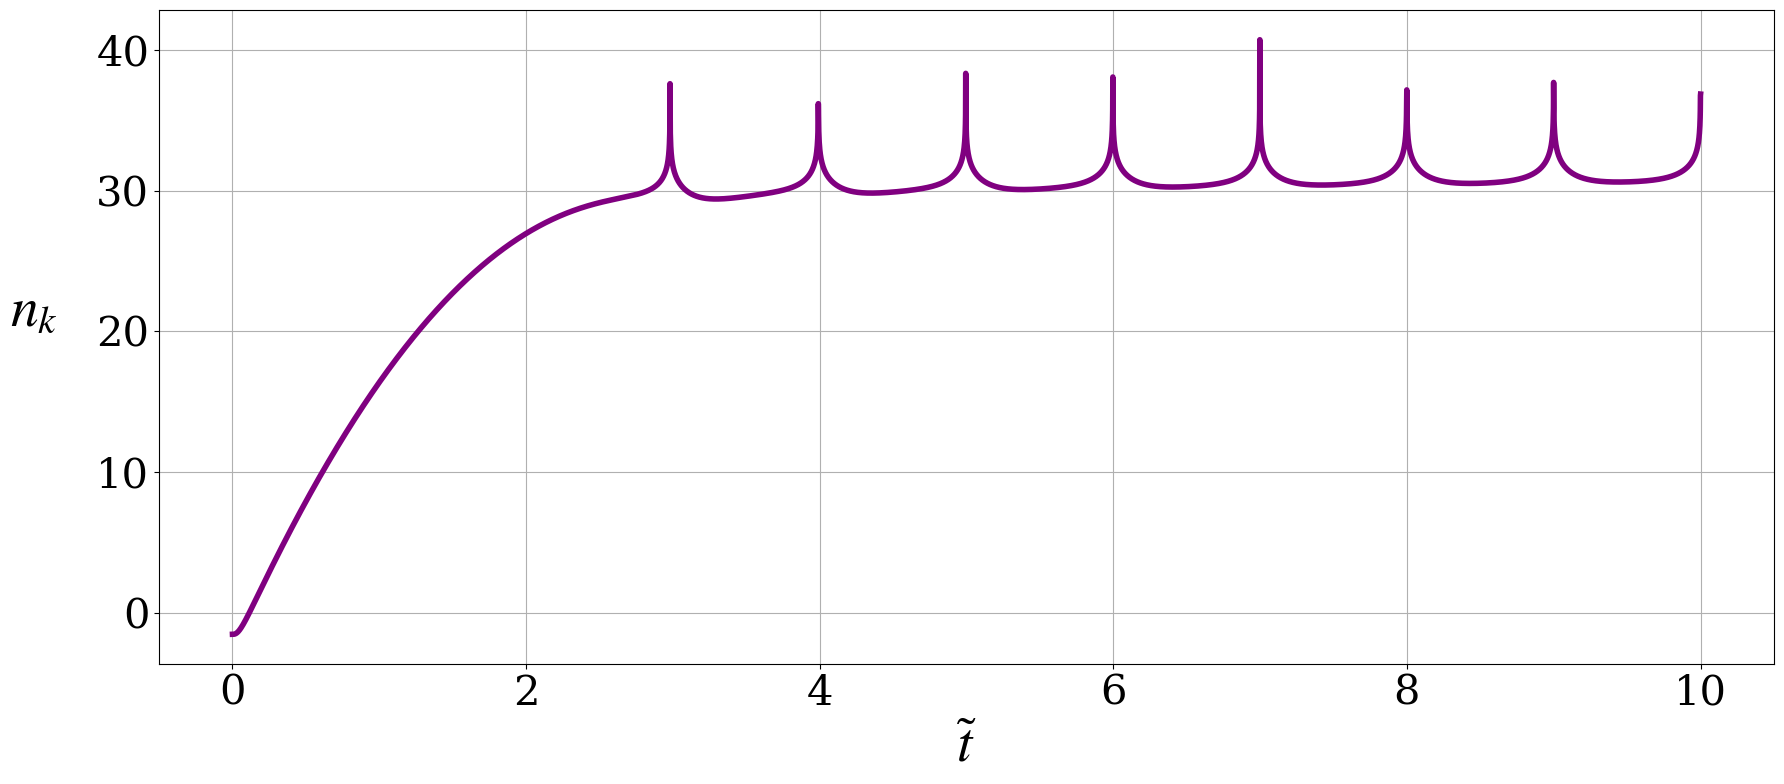

In [12]:
# Resuelve el sistema
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g_mplm2), t_eval=t_eval, method="Radau", rtol=1e-8, atol=1e-8)

# Extrae resultados
a_sol = sol.y[6]
adot_sol = sol.y[7]
chi_sol = sol.y[4]
chidot_sol = sol.y[5]
phi_sol = sol.y[0]

x_dot = (3/2)*np.sqrt(a_sol/a_sol[0]) * adot_sol / a_sol[0] * chi_sol + (a_sol/a_sol[0])**(3/2) * chidot_sol
x = (a_sol/a_sol[0])**(3/2) * chi_sol
omega_k = np.sqrt((k/a_sol)**2 + g_mplm2 * phi_sol**2)
nk = omega_k / 2 * (np.abs(x_dot)**2 / omega_k**2 + np.abs(x)**2)

plt.figure(figsize=(18, 8))
plt.plot(sol.t/np.pi, np.log(nk), lw=4, color="purple")
plt.ylabel(r"$n_k$", labelpad=45, rotation="horizontal", fontsize=40)
plt.xlabel(r"$\tilde{t}$", fontsize=40)
plt.grid()
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.savefig("Narrow_resonance", format="pdf")

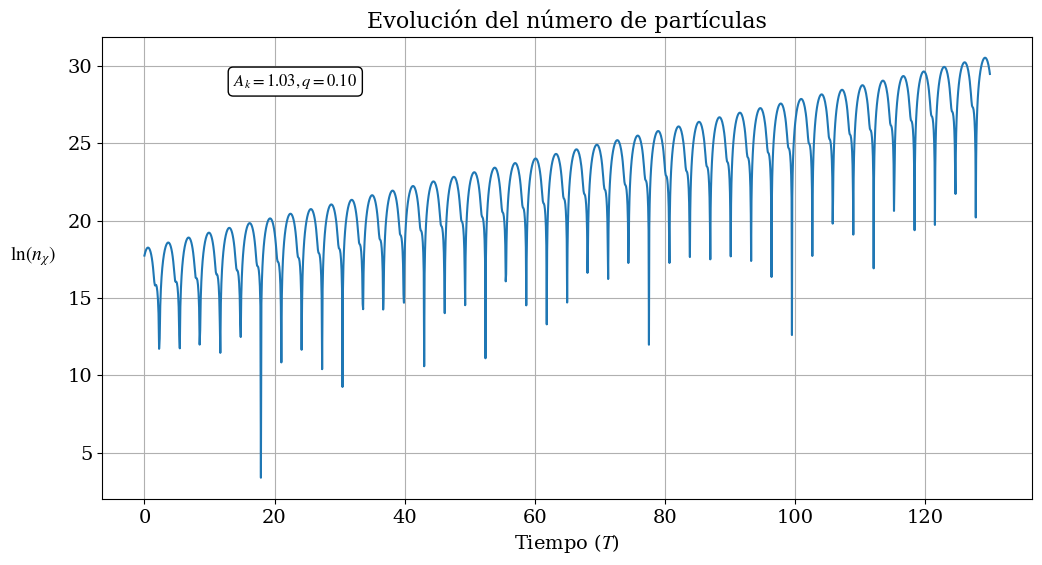

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros iniciales
T0, Tf = 0, 130           # Intervalo de tiempo
q = 0.1                   # Parámetro q de MathieU (modificar para resonancia estrecha/ancha)
Ak = 1.03                 # Parámetro A_k de Mathieu
phi_0 = 1.0               # Amplitud inicial del campo inflatón (definir valor)

g = 1e8                   # Constante de acoplamiento (definir valor)

# Definimos la ecuación diferencial Mathieu en forma de sistema de primer orden
def mathieu(t, y, Ak, q):
    u, v = y
    du_dt = v
    dv_dt = - (Ak - 2 * q * np.cos(2 * t)) * u
    return [du_dt, dv_dt]

# Condiciones iniciales para y y y'
u0 = 1.0                  # Por ejemplo, u(0) = 1
v0 = 1.0                  # y'(0) = 0

# Obtener masa y número de onda k
m = g / 2 * phi_0 * np.sqrt(q)
k = np.sqrt(Ak - 2 * q) * m

# Resolver la ecuación diferencial
sol = solve_ivp(mathieu, [T0, Tf], [u0, v0], args=(Ak, q), rtol=1e-8, atol=1e-8, dense_output=True)
T = sol.t
y = sol.y[0]
y_prime = sol.y[1]

# Campo inflatón como potencial armónico simple
phi = phi_0 * np.cos(T)

# Suponemos a(t) = 1 (o constante) para simplicidad, definir si deseás variable
a = 1.0

# Frecuencia del campo hijo (chi)
Omega_chi = np.sqrt((k**2 / a**2) + (g**2 * phi**2))

# Número de partículas (ocupación) del campo hijo
n = 1 / (2 * Omega_chi) * (np.abs(y_prime)**2 + Omega_chi**2 * np.abs(y)**2) - 0.5

# Graficar ln(n)
plt.plot(T, np.log(np.abs(n)))
plt.xlabel(r'Tiempo ($T$)')
plt.ylabel(r'$\ln (n_\chi)$', labelpad=25, rotation='horizontal')
plt.title('Evolución del número de partículas')
plt.yscale('linear')
plt.grid(True)

# Insertar caja con parámetros en la gráfica
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
plt.text(x=0.1 * xmax, y=0.9 * ymax,
         s=rf'$A_k = {Ak:.2f}, q = {q:.2f}$',
         fontsize=12,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

plt.show()

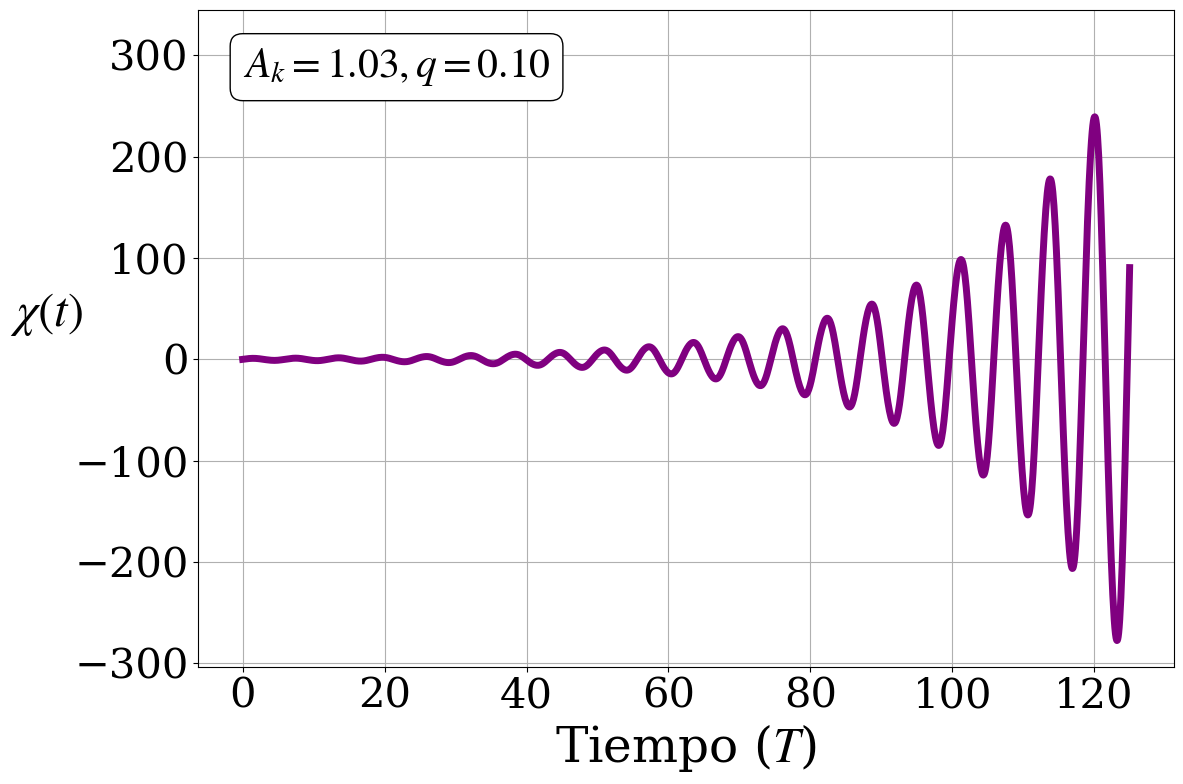

In [14]:
# Centrémosnos sólo en el que tiene A_k = 1.03 y q = 0.1
u0, v0 = 0, 1                                           # Condiciones iniciales
T0, Tf = 0, 125                                         # Tiempos
q = 0.1                             
Ak = 1.03

sol = solve_ivp(mathieu, [T0, Tf], [u0, v0], args=(Ak, q), rtol=1e-8, atol=1e-8)
T, y, y_prime = sol.t, sol.y[0], sol.y[1]

# Graficamos los resultados
plt.figure(figsize=(12, 8))
plt.plot(T, y, lw = 5, color = "purple")
plt.xlabel(r'Tiempo ($T$)', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.text(x=T[0], y=ymax*1.05, s=rf'$A_k = {Ak:.2f}, q = {q:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid()
plt.tight_layout()
#plt.show()

#plt.savefig("narrow_resonance", format='pdf')

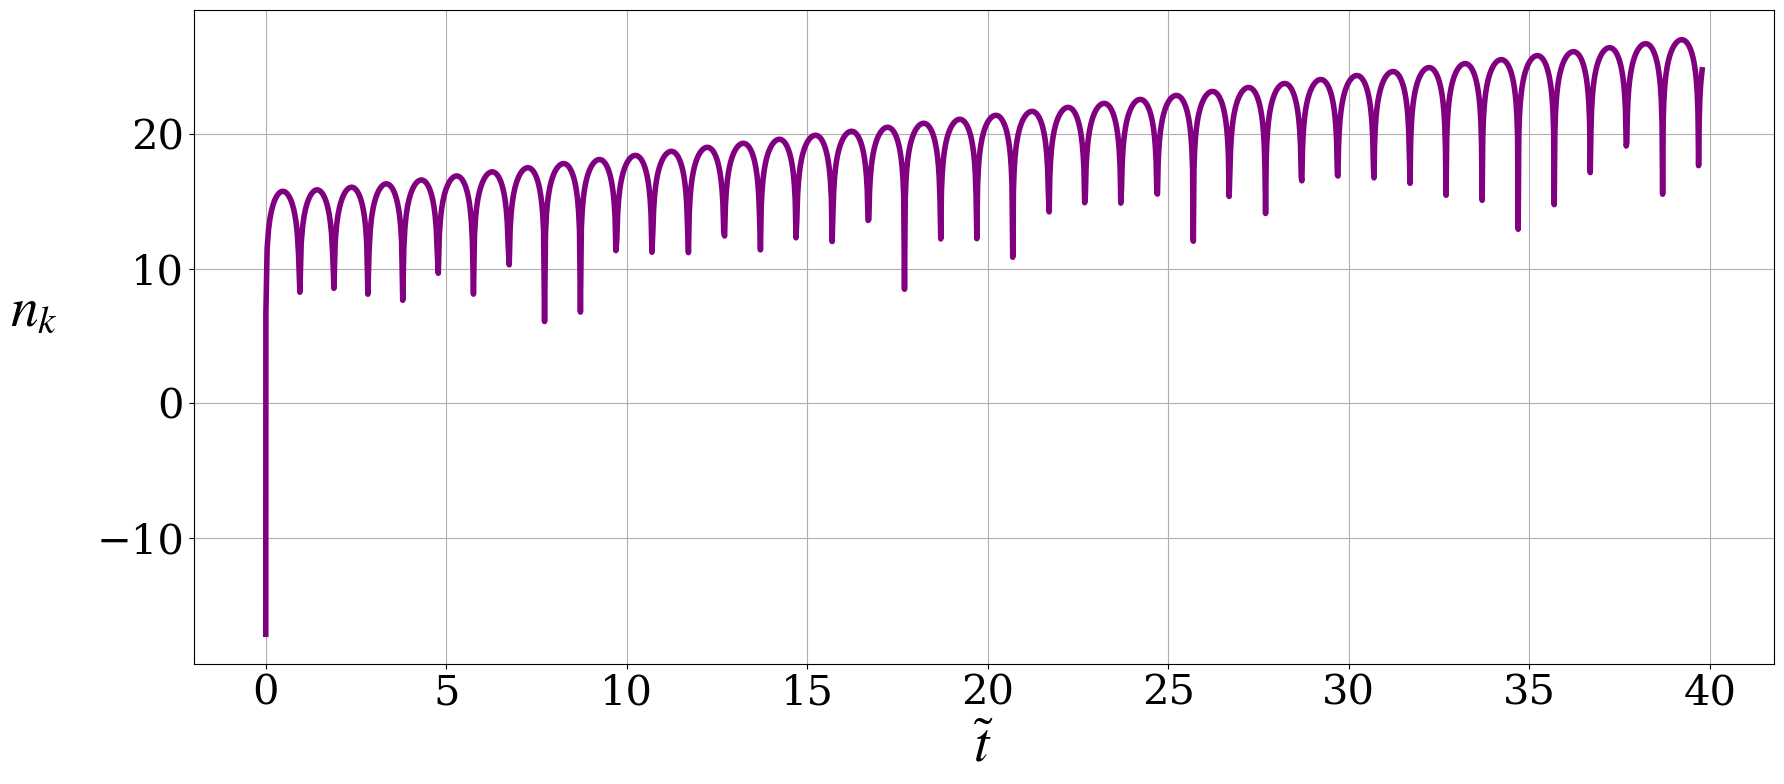

In [15]:
phi = np.cos(T)

omega_k = np.sqrt( k**2 + g_mplm2 * phi**2 ) # - (3/2) Hprime - 9/4H**2

nk = omega_k / 2 * ( np.abs(y_prime)**2 / omega_k**2 + np.abs(y)**2 )

plt.figure(figsize = (18, 8))

plt.plot(sol.t/np.pi, np.log(nk), lw = 4, color = "purple")
plt.ylabel(r"$n_k$", labelpad = 45, rotation = "horizontal", fontsize = 40)
plt.xlabel(r"$\tilde{t}$", fontsize = 40)
plt.grid()

plt.xticks(fontsize = 30)
plt.yticks(fontsize = 30)
plt.tight_layout()